## EDA Notebook

In [16]:

import pandas as pd
import numpy as np
import sweetviz as sv
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder




In [5]:

LOCAL_PATH = "playground-series-s6e4"

if os.path.exists("/kaggle/input/playground-series-s6e4"):
    # Running on Kaggle
    train = pd.read_csv("/kaggle/input/playground-series-s6e4/train.csv")
    test = pd.read_csv("/kaggle/input/playground-series-s6e4/test.csv")
else:
    # Running locally
    train = pd.read_csv(f"{LOCAL_PATH}/train.csv")
    test = pd.read_csv(f"{LOCAL_PATH}/test.csv")

In [19]:
train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [6]:
#create sweetviz report
report = sv.analyze(train)
report.show_html()

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [7]:
train["Irrigation_Need"].value_counts(normalize=True)

Irrigation_Need
Low       0.587170
Medium    0.379483
High      0.033348
Name: proportion, dtype: float64

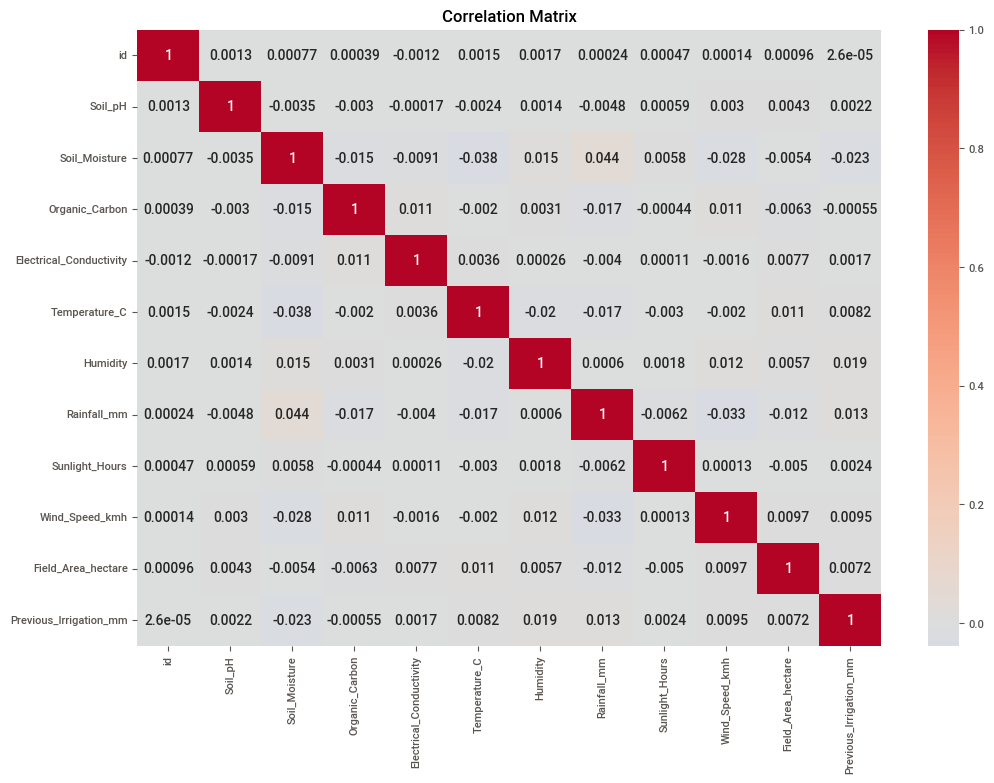

In [13]:

numeric_cols = train.select_dtypes(include="number").columns

plt.figure(figsize=(12,8))
corr = train[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot = True)
plt.title("Correlation Matrix")
plt.show()

In [18]:

# target
le = LabelEncoder()
y = le.fit_transform(train["Irrigation_Need"])

# features
X = train.drop(columns=["Irrigation_Need", "id"])

# one-hot encode categorical columns
X_encoded = pd.get_dummies(X, drop_first=False)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_encoded, y)

importances = pd.Series(
    rf.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

print(importances.head(20))

Soil_Moisture                   0.272519
Wind_Speed_kmh                  0.112726
Temperature_C                   0.112483
Crop_Growth_Stage_Harvest       0.075333
Crop_Growth_Stage_Sowing        0.073068
Crop_Growth_Stage_Flowering     0.066854
Crop_Growth_Stage_Vegetative    0.066827
Mulching_Used_Yes               0.046824
Mulching_Used_No                0.044335
Rainfall_mm                     0.037514
Previous_Irrigation_mm          0.011968
Humidity                        0.010473
Field_Area_hectare              0.008798
Sunlight_Hours                  0.008632
Electrical_Conductivity         0.008549
Soil_pH                         0.008535
Organic_Carbon                  0.007902
Soil_Type_Sandy                 0.001106
Irrigation_Type_Canal           0.001102
Season_Zaid                     0.001099
dtype: float64


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

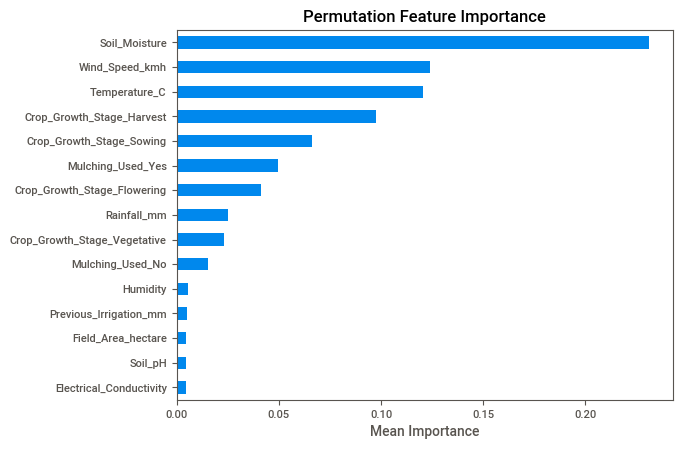

In [23]:
X_sample = X_encoded.sample(50000, random_state=42)
y_sample = y[X_sample.index]

result = permutation_importance(
    rf,
    X_sample,
    y_sample,
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.Series(
    result.importances_mean,
    index=X_encoded.columns
).sort_values(ascending=False)

perm_importance.head(15).sort_values().plot(kind="barh")
plt.title("Permutation Feature Importance")
plt.xlabel("Mean Importance")
plt.show()